In [2]:
import pandas as pd

books = pd.read_csv("../data/books.csv")
customers = pd.read_csv("../data/customers.csv")
sales = pd.read_csv("../data/sales.csv")

print("Books Data")
display(books.head())

print("Customers Data")
display(customers.head())

print("Sales Data")
display(sales.head())

Books Data


,Book_ID,Title,Author,Category,Price,Stock
0,B001,Python Basics,John Smith,Programming,499,50
1,B002,Advanced Python,Sarah Wilson,Programming,699,40
2,B003,Machine Learning Handbook,Andrew Brown,AI,899,30
3,B004,Deep Learning Guide,David Lee,AI,999,25
4,B005,Data Science Essentials,Emma Davis,Data Science,799,35


Customers Data


,Customer_ID,Name,Age,Gender,City
0,C001,Rahul Sharma,22,M,Hyderabad
1,C002,Priya Verma,24,F,Delhi
2,C003,Amit Kumar,21,M,Mumbai
3,C004,Neha Singh,23,F,Bangalore
4,C005,Rohit Gupta,25,M,Pune


Sales Data


,Sale_ID,Book_ID,Customer_ID,Quantity,Date
0,S001,B001,C001,2,2025-01-05
1,S002,B003,C002,1,2025-01-07
2,S003,B002,C003,3,2025-01-10
3,S004,B005,C004,1,2025-01-12
4,S005,B004,C005,2,2025-01-15


In [3]:
import pandas as pd

books = pd.read_csv("../data/books.csv")
customers = pd.read_csv("../data/customers.csv")
sales = pd.read_csv("../data/sales.csv")

print(books.shape)
print(customers.shape)
print(sales.shape)

(11, 6)
(10, 5)
(11, 5)


In [4]:
merged = pd.merge(
    sales,
    books,
    on="Book_ID"
)

merged = pd.merge(
    merged,
    customers,
    on="Customer_ID"
)

merged.head()

,Sale_ID,Book_ID,Customer_ID,Quantity,Date,Title,Author,Category,Price,Stock,Name,Age,Gender,City
0,S001,B001,C001,2,2025-01-05,Python Basics,John Smith,Programming,499.0,48,Rahul Sharma,22,M,Hyderabad
1,S002,B003,C002,1,2025-01-07,Machine Learning Handbook,Andrew Brown,AI,899.0,30,Priya Verma,24,F,Delhi
2,S003,B002,C003,3,2025-01-10,Advanced Python,Sarah Wilson,Programming,699.0,40,Amit Kumar,21,M,Mumbai
3,S004,B005,C004,1,2025-01-12,Data Science Essentials,Emma Davis,Data Science,799.0,35,Neha Singh,23,F,Bangalore
4,S005,B004,C005,2,2025-01-15,Deep Learning Guide,David Lee,AI,999.0,25,Rohit Gupta,25,M,Pune


In [5]:
merged["Revenue"] = (
    merged["Quantity"] *
    merged["Price"]
)

merged["Revenue"].sum()

np.float64(13830.0)

In [6]:
top_books = merged.groupby(
    "Title"
)["Quantity"].sum()

top_books.sort_values(
    ascending=False
)

Title
Python Basics                8
Advanced Python              3
Machine Learning Handbook    3
Deep Learning Guide          2
Data Science Essentials      1
Computer Vision Basics       1
SQL Mastery                  1
Statistics for ML            1
Name: Quantity, dtype: int64

In [7]:
category_sales = merged.groupby(
    "Category"
)["Revenue"].sum()

category_sales

Category
AI              5694.0
Data Science     799.0
Database         599.0
Mathematics      649.0
Programming     6089.0
Name: Revenue, dtype: float64

In [8]:
top_customers = merged.groupby(
    "Name"
)["Revenue"].sum()

top_customers.sort_values(
    ascending=False
)

Name
Amit Kumar      2097.0
Rohit Gupta     1998.0
Rahul Sharma    1996.0
Karan Mehta     1996.0
Vikram Patel    1798.0
Pooja Jain       999.0
Priya Verma      899.0
Neha Singh       799.0
Sneha Reddy      649.0
Ananya Rao       599.0
Name: Revenue, dtype: float64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

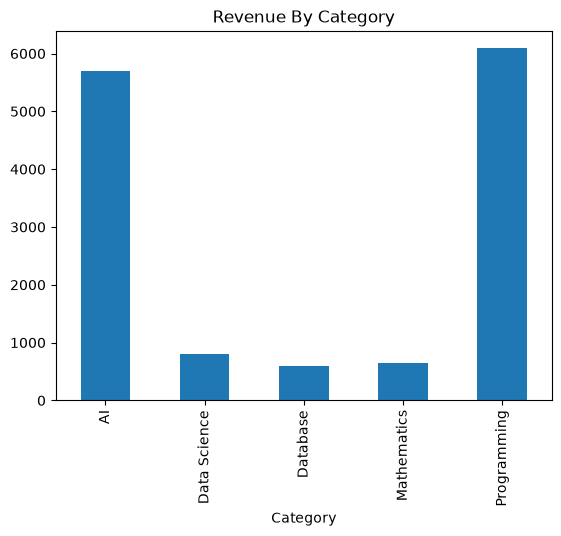

In [10]:
category_sales.plot(
    kind="bar"
)

plt.title("Revenue By Category")
plt.show()


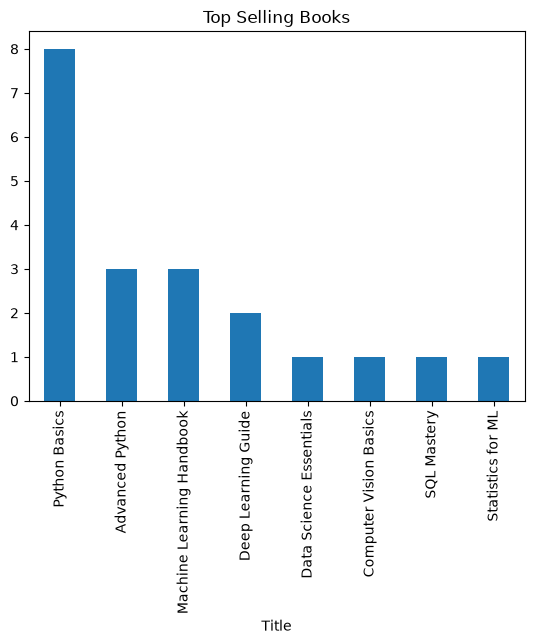

In [11]:
top_books.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title("Top Selling Books")
plt.show()

In [12]:
low_stock = books[
    books["Stock"] < 20
]

low_stock


,Book_ID,Title,Author,Category,Price,Stock
9,B010,Computer Vision Basics,Olivia Moore,AI,999.0,15


In [13]:
category_sales.to_csv(
    "../reports/category_sales.csv"
)

top_books.to_csv(
    "../reports/top_books.csv"
)